In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from utils.model_saver import *
from utils.model_classes import XGBModel

PROJECT_ROOT = Path().resolve().parent.parent.parent
print(f"Project root: {PROJECT_ROOT}")
PATH_DATA = PROJECT_ROOT / 'data' / 'exploded_splits'
print(f"Data: {PATH_DATA}")

TEXTUAL_EMBEDDING_PATH = PROJECT_ROOT / 'data' / 'textual_features'
MODEL_SAVE_PATH = PROJECT_ROOT / 'Models'
text_emb_128 = TEXTUAL_EMBEDDING_PATH / 'textual_embeddings_128.parquet'

RANDOM_STATE = 42

import torch
# Detect device: 'cuda' if available, else 'cpu'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

# for parallelization
N_JOBS = -1

Using device: cuda
Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1
Data: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/data/exploded_splits
Using device: cuda


# XGBoost Model - on textual embeddings 128
By leveraging 128-dimensional textual embeddings representing paper content, this notebook treats citation prediction as a supervised binary classification task.

To ensure code quality and reusability, we use the shared model hierarchy:

- `BaseModel`: an abstract class that defines the common contract for preprocessing, training, prediction, evaluation, and saving.
- `XGBModel`: the concrete XGBoost implementation. It drops non-feature columns, applies `RobustScaler` consistently across splits, and trains a gradient-boosted tree classifier.


## 1. Load embedding data

In [2]:
df = pd.read_parquet(text_emb_128)
display(df.head())
print(df.shape)

,split,article_id,ref_id,is_reference_valid,article_emb_000,article_emb_001,article_emb_002,article_emb_003,article_emb_004,article_emb_005,...,ref_emb_118,ref_emb_119,ref_emb_120,ref_emb_121,ref_emb_122,ref_emb_123,ref_emb_124,ref_emb_125,ref_emb_126,ref_emb_127
0,train,53e99f0ab7602d97027d6a89,53e99ff0b7602d97028d14d3,1,0.256074,-0.008567,0.029547,0.027875,-0.039097,0.061652,...,0.064212,0.001819,0.028266,0.074405,-0.012687,-0.012413,-0.018658,0.019843,-0.018603,-0.062412
1,train,53e9bd81b7602d9704a24d06,557f4d4f6fee0fe990cb035f,1,0.177240,0.009653,-0.006376,0.139197,0.036759,0.024399,...,-0.002640,0.002758,-0.021711,0.000173,0.036031,0.010025,-0.032560,-0.004902,0.012356,-0.037394
2,train,539087fe20f70186a0d75db6,539087ae20f70186a0d4cf5a,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,-0.025537,0.005557,0.027970,0.036103,0.017138,-0.040106,0.029802,-0.020301,-0.001983,-0.039484
3,train,539087fe20f70186a0d75db6,5390878e20f70186a0d3a260,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,0.022904,0.030194,0.019120,-0.022178,-0.037727,0.054251,-0.055143,0.056518,-0.040537,-0.131712
4,train,539087fe20f70186a0d75db6,539087cb20f70186a0d58fe1,1,0.279532,-0.065988,0.088996,-0.124474,0.029969,-0.064352,...,-0.028705,-0.019178,-0.046387,-0.040602,0.018601,0.018564,0.042588,0.064933,0.001457,0.016216


(2950135, 260)


In [3]:
# splitting
split_series = df["split"].astype(str).str.lower()
df_train = df[split_series == "train"].copy()
df_val = df[split_series.isin(["validation", "val"])].copy()
df_test = df[split_series == "test"].copy()

ID_COLUMNS = ["article_id", "ref_id"]
df_train = df_train.drop(columns=ID_COLUMNS, errors="ignore")
df_val = df_val.drop(columns=ID_COLUMNS, errors="ignore")
df_test = df_test.drop(columns=ID_COLUMNS, errors="ignore")

print("\nSplit sizes:", {"train": len(df_train), "test": len(df_test), "val": len(df_val)})


Split sizes: {'train': 2162513, 'test': 396380, 'val': 391242}


## 2. Baseline model

[XGB_baseline] Preprocessing 2162513 rows...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[XGB_baseline] Starting training...


/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [15:04:28] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1772125072520/work/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1080179
           1     1.0000    1.0000    1.0000   1082334

    accuracy                         1.0000   2162513
   macro avg     1.0000    1.0000    1.0000   2162513
weighted avg     1.0000    1.0000    1.0000   2162513



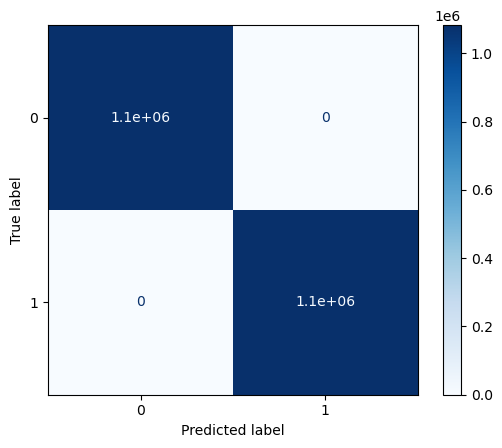

In [4]:
XGB_baseline = XGBModel('XGB_baseline', tree_method="hist")
XGB_baseline.train_pipeline(df_train, frac=1)

The confusion matrix for the training set shows an accuracy of 100%. This indicates severe overfitting, which is most likely to happen for high-capacity models like XGBoost that can easily memorize the pattern of the training set, but completely fail to generalize for unseen data.

[XGB_baseline] Preprocessing 396380 rows...
Label distribution:
is_reference_valid
1    0.500003
0    0.499997
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.8116    0.8079    0.8097    198189
           1     0.8088    0.8124    0.8106    198191

    accuracy                         0.8102    396380
   macro avg     0.8102    0.8102    0.8102    396380
weighted avg     0.8102    0.8102    0.8102    396380



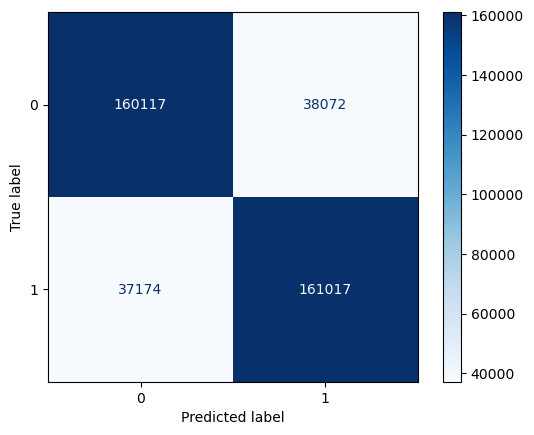

In [5]:
XGB_baseline.test_pipeline(df_test)

The baseline XGBoost model using 128-dimensional textual features achieved an accuracy of 81.02%. The confusion matrix indicates a highly balanced performance, with nearly identical precision and recall for both valid and invalid referecenes.

## 3. Hyperparameter tuning
Because XGBoost exposes many interacting hyperparameters, an exhaustive grid search would be too expensive on the full dataset. The notebook therefore uses `RandomizedSearchCV`, which samples a fixed number of configurations from the defined parameter distributions.

This approach explores learning rate, tree depth, sampling, and regularization options efficiently while keeping the tuning run manageable on large feature matrices.


In [6]:
# Valid hyperparameters for XGBClassifier
param_dist = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1, 5, 10],
    "scale_pos_weight": [1, 2, 5],
}

[XGB_textual_128] Grid Search...
[XGB_textual_128] Preprocessing 2162513 rows...
Label distribution:
is_reference_valid
1    0.500002
0    0.499998
Name: proportion, dtype: float64
[XGB_textual_128] Preprocessing 391242 rows...
Label distribution:
is_reference_valid
1    0.5
0    0.5
Name: proportion, dtype: float64
[XGB_textual_128] CUDA detected: using n_jobs=1 for RandomizedSearchCV to avoid running multiple GPU fits at the same time.
Fitting 2 folds for each of 20 candidates, totalling 40 fits
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=10, n_estimators=100, reg_lambda=5, scale_pos_weight=5, subsample=1.0; total time=  20.9s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=10, n_estimators=100, reg_lambda=5, scale_pos_weight=5, subsample=1.0; total time=  22.5s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, reg_lambda=10, scale_pos_weight=5, subsample=0.8; total time=   9.5s
[CV] END colsample_bytree=0.8, learning_rate

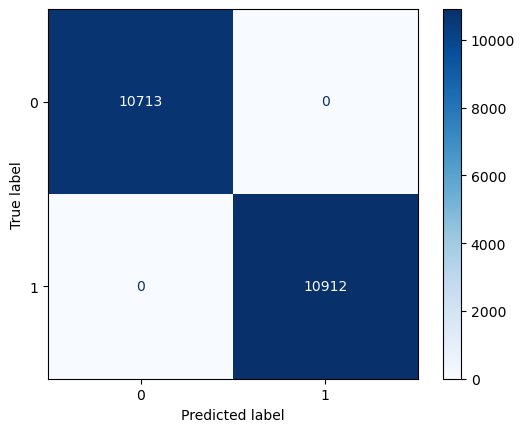

In [7]:
# tuning
XGB_textual_128 = XGBModel("XGB_textual_128", tree_method="hist")
XGB_textual_128.hypertune_pipeline(df_train, df_val, param_dist, 
                            n_iter=20,
                            cv=2,
                            scoring="f1",
                            random_state=RANDOM_STATE,
                            n_jobs=N_JOBS,
                            pre_dispatch=N_JOBS,
                            error_score="raise",
                            verbose=2,
                        )

## 4. Final model with best parameters
Once the best XGBoost configuration is selected, the estimator is retrained through the shared training pipeline and evaluated on the held-out test split.

Performance is assessed using:
- Weighted F1-score, to summarize class-balanced performance.
- Confusion matrix, to visualize false positives and false negatives.
- Classification report, with precision, recall, F1-score, and accuracy.


[XGB_textual_128] Preprocessing 396380 rows...
Label distribution:
is_reference_valid
1    0.500003
0    0.499997
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0     0.8291    0.8629    0.8456    198189
           1     0.8570    0.8221    0.8392    198191

    accuracy                         0.8425    396380
   macro avg     0.8431    0.8425    0.8424    396380
weighted avg     0.8431    0.8425    0.8424    396380



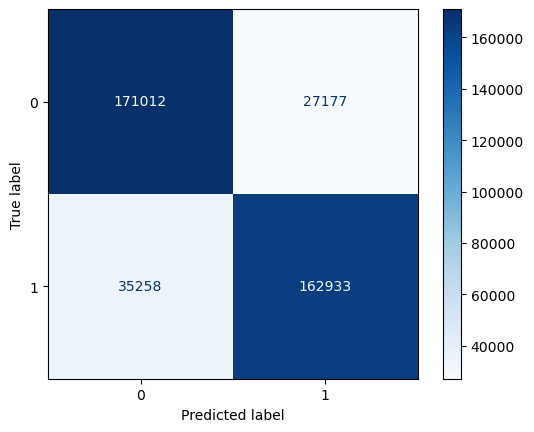

In [8]:
# final training creating model with best params
XGB_textual_128.test_pipeline(df_test)

After hyperparameter tuning, the model reach a 84.25% of accuracy. which is an improvement of 3% respect to the baseline. But the model seems like to wrongly classify negatives predictions. correctly classifying 82% of the time.

## 5. Save the pretrained model
Finally, the trained model is saved with the custom `save_model_artifact` utility, so it can be reused for later evaluation, explainability, or deployment experiments.


In [9]:
from utils.model_saver import save_model_artifact

save_model_artifact(XGB_textual_128, df_name=text_emb_128.name, 
                    model_name="Best_XGB_textual_128", 
                    relative_model_dir=MODEL_SAVE_PATH)